# **Movie Recommendation System Using Collaborative Filtering**

---

# **1. Business Understanding**

---

Streaming platforms such as Netflix and Amazon Prime contain a large number of movies.

This creates a problem where users struggle to find movies they want to watch due to too many choices.

The goal of this project is to build a recommendation system that suggests movies to users based on their past ratings.

## **1.1 — Stakeholders**

The main stakeholders in this project are:

- Streaming platforms (e.g., Netflix-style services)
- Movie viewers (users)
- Data science teams

These stakeholders benefit from improved movie recommendations that enhance user experience and engagement.

## **1.2 — Business Value**

This system provides value by:

- Helping users find movies they are likely to enjoy
- Increasing user engagement on streaming platforms
- Improving content discovery efficiency
- Reducing time spent searching for movies

## Conclusion

This project addresses a real-world problem of helping users discover movies in large streaming libraries.

It improves user satisfaction and helps platforms increase engagement through better recommendations.


#  **2. Data Understanding — MovieLens 100K Dataset**


---

##  Data Source

This project uses the MovieLens 100K dataset provided by GroupLens Research (University of Minnesota).

The dataset is widely used in recommendation system research and contains real user ratings of movies.

## **2.1 — Dataset Description**

The dataset contains three main files:

- u.data → user ratings (userId, movieId, rating, timestamp)
- u.item → movie information (movie titles and genres)
- u.user → user demographic information (age, gender, occupation)

For this project, we mainly use:
- userId
- movieId
- rating

In [420]:
#1. loading the data
import pandas as pd

# Load ratings data (main dataset for recommendation system)
ratings = pd.read_csv(
    "data/ml-100k/u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

# Load full movie information including genres
movies_raw = pd.read_csv(
    "data/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

# Extract just movieId and title for common use
movies = movies_raw[[0, 1]]

# Rename columns for clarity
movies.columns = ["movieId", "title"]

In [421]:
#2. checking the size of the datasets
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Ratings shape: (100000, 4)
Movies shape: (1682, 2)


In [422]:
#3. Check column names
print("Ratings columns:", ratings.columns)
print("Movies columns:", movies.columns)

Ratings columns: Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Movies columns: Index(['movieId', 'title'], dtype='object')


In [423]:
#4. View first rows of dataset
ratings.head()

,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [424]:
movies.head()

,movieId,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [425]:
#5. Summary of the ratings dataset
ratings.describe()

,userId,movieId,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


## **2.2 — Data Visualization & Insights**

Visuals are used in this project to make model results and data patterns easier to understand for non-technical stakeholders.

Since recommendation systems involve numerical outputs such as ratings and error metrics (e.g., RMSE), visualizations help translate these results into clear comparisons and insights as we shall see later in modeling and model comparison stages.

In particular, visuals help to:
- Compare the performance of different models (Baseline, KNN, SVD) this will be shown in modeling stage.

- Make patterns in user ratings and predictions easier to interpret this is shown in data understanding stage.

- Support decision-making by clearly showing which model performs best
- Communicate results in a way that is accessible to business stakeholders

Overall, visuals improve clarity, interpretability, and the ability to communicate the value of the recommendation system.

#### 2.2.1 Distribution Of Ratings 

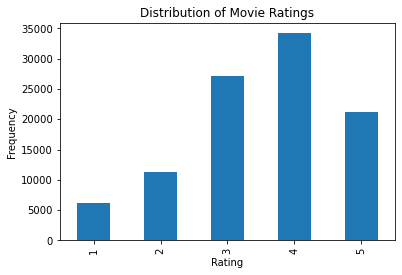

In [426]:
# 1. distribution of ratings
import matplotlib.pyplot as plt

ratings["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

## Rating Distribution

This graph shows how users rate movies on the platform.

Understanding rating distribution is important because recommendation models learn from these ratings. If ratings are heavily concentrated around certain values, this may influence model predictions.

#### 2.2.2 Most Rated Movie

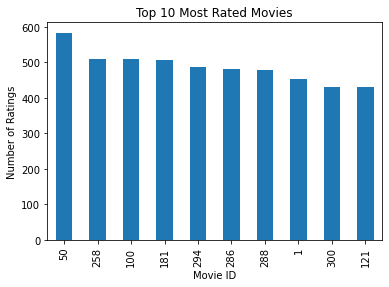

In [427]:
# 2. most rated movies
movie_counts = ratings["movieId"].value_counts().head(10)

movie_counts.plot(kind="bar")

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.show()

## Most Rated Movies

This visualization identifies movies that receive the highest number of ratings.

Popular movies often have more reliable rating information because they have been evaluated by many users.

#### 2.2.3 Rating Per User

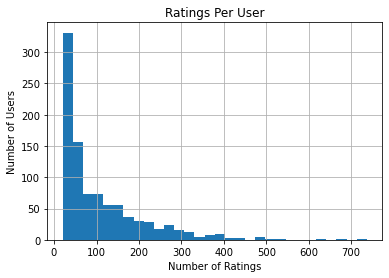

In [428]:
# 3. ratings per user
user_counts = ratings.groupby("userId")["rating"].count()

user_counts.hist(bins=30)

plt.title("Ratings Per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

## User Activity

This visualization shows how many ratings each user has submitted.

Understanding user activity helps determine whether sufficient information exists to learn user preferences.

#### 2.2.4 Averange Rating vs Movie Popularity

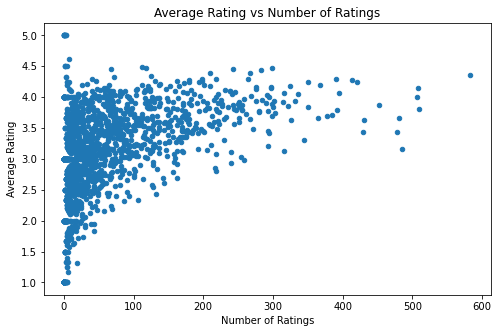

In [429]:
# 3. average rating by movie popularity
# Calculate movie statistics
movie_stats = ratings.groupby("movieId").agg({
    "rating": ["count", "mean"]
})

movie_stats.columns = ["rating_count", "average_rating"]

# Scatter plot
movie_stats.plot(
    kind="scatter",
    x="rating_count",
    y="average_rating",
    figsize=(8, 5)
)

plt.title("Average Rating vs Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()

## Relationship Between Popularity and Rating

This scatter plot compares the number of ratings a movie receives with its average rating.

This scatter plot helps identify whether highly-rated movies are also popular among users. This insight is useful because recommendation systems often rely on both popularity and user preferences.

#### 2.2.5 Genre Distribution

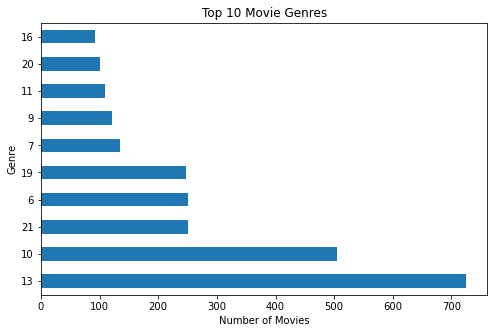

In [430]:
#  top genre in dataset
# Genre columns in MovieLens 100K start after column 4
genre_counts = movies_raw.iloc[:, 5:].sum().sort_values(ascending=False)

genre_counts.head(10).plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

## Genre Distribution

This chart shows the most common genres in the dataset.

Understanding genre distribution helps identify whether certain movie categories dominate the dataset and may influence recommendation results.

#### 2.2.6 Rating Over Time

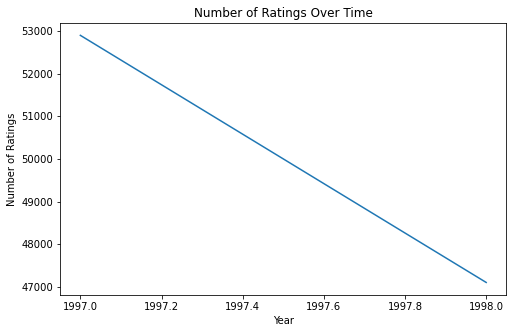

In [431]:
# 5. rating over time
# Convert timestamp to datetime
ratings["date"] = pd.to_datetime(ratings["timestamp"], unit="s")

# Count ratings by year
ratings_by_year = ratings.groupby(
    ratings["date"].dt.year
).size()

ratings_by_year.plot(
    kind="line",
    figsize=(8, 5)
)

plt.title("Number of Ratings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.show()

## Ratings Activity Over Time

This line chart shows how rating activity changes over time.

Analyzing temporal trends helps us understand user engagement patterns and provides additional context about the dataset.

Each row in the ratings dataset represents:

A user (userId) giving a rating (1–5) to a movie (movieId).

This forms a user-item interaction matrix, which is the foundation of recommendation systems.

## **2.3 — Why This Dataset?**

This dataset is useful because:

- It contains real user preferences (ratings)
- It allows prediction of missing ratings
- It helps find users with similar tastes
- It supports collaborative filtering models like SVD

## **2.4 — Features Used in Analysis**

We focus on:

- userId → identifies users
- movieId → identifies movies
- rating → user preference score (1–5)

These features are essential for learning user behavior patterns.

## **2.5 — Data Limitations**

- Only explicit ratings are available (no watch history)
- Cold start problem exists for new users
- Data is sparse (many missing user-movie combinations)
- No modern behavioral signals like clicks or watch time

#  **3. Data Preparation & Feature Engineering**


---

In this stage, we prepare the raw MovieLens dataset so it can be used for building a recommendation model.

This includes:
- Loading the data
- Merging datasets
- Checking for missing values
- Creating a user-item matrix
- Splitting data into training and testing sets

These steps make the data suitable for collaborative filtering models.

### **3.1 — Loading & Merging Datasets**


In [432]:
# 1. load the data
import pandas as pd

# Load ratings data
# This contains user ratings for movies
ratings = pd.read_csv(
    "data/ml-100k/u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

# Load movie information
# This helps us map movie IDs to readable movie titles
movies = pd.read_csv(
    "data/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)[[0, 1]]

# Rename columns for clarity
movies.columns = ["movieId", "title"]

### **3.2 — Merging Ratings with Movie Information**


In [433]:
# 2. We combine ratings with movie titles
# This helps us understand which movie each rating belongs to

df = pd.merge(ratings, movies, on="movieId")

# Show first few rows to confirm merge worked
df.head()

,userId,movieId,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,63,242,3,875747190,Kolya (1996)
2,226,242,5,883888671,Kolya (1996)
3,154,242,3,879138235,Kolya (1996)
4,306,242,5,876503793,Kolya (1996)


This step joins the ratings dataset with the movies dataset.

Why this is important:
- Ratings alone only contain movie IDs (not names)
- Merging allows us to interpret results in a human-readable way

### **3.3 — Data Quality Check**


In [434]:
# Check for missing values in each column
df.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
title        0
dtype: int64

This step checks if any data is missing.

Why this matters:
- Missing values can cause errors in modeling
- MovieLens dataset is already clean, but we verify it anyway

### **3.4 — Filtering Valid Ratings**


In [435]:
# Ensure ratings are within valid range (1 to 5)
df = df[(df["rating"] >= 1) & (df["rating"] <= 5)]
df["rating"].describe()

count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

We filter ratings to ensure data consistency.

Why:
- MovieLens ratings are expected to be between 1 and 5
- This removes any incorrect or corrupted values

### **3.5 — Creating User-Item Interaction Matrix**


In [436]:
# Create a matrix where:
# rows = users
# columns = movies
# values = ratings

user_item_matrix = df.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
userId,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This is one of the most important steps in recommendation systems.

We convert the dataset into a user-item matrix:

- Each row represents a user
- Each column represents a movie
- Each cell contains the rating given by a user to a movie

This structure is required for collaborative filtering models like SVD.

### **3.6 — Analyzing Data Sparsity**


In [437]:
# 1.Count missing values in the matrix
missing_values = user_item_matrix.isnull().sum().sum()
print("Total missing values in user-item matrix:", missing_values)



Total missing values in user-item matrix: 1486126


In [438]:
# 2. total possible values in the matrix
total_values = user_item_matrix.size
print("Total possible values in user-item matrix:", total_values)

Total possible values in user-item matrix: 1586126


In [439]:
# 3. Calculate sparsity
print("missing_values:", missing_values)
print("Sparsity(%):", (missing_values / total_values) * 100)

missing_values: 1486126
Sparsity(%): 93.69533063577546


This step measures how sparse the dataset is.

Why this matters:
- Most users have NOT rated most movies
- This sparsity is what makes recommendation systems challenging
- Collaborative filtering is designed to handle this issue

### **3.7 — Train-Test Split**


In [440]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# Training data is used to build the model
# Test data is used to evaluate the model

train_data, test_data = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print("Train size:", train_data.shape)
print("Test size:", test_data.shape)

Train size: (80000, 5)
Test size: (20000, 5)


We split the dataset into training and testing sets.

Why:
- Training data is used to build the model
- Test data is used to evaluate performance on unseen data
- This ensures fair evaluation and prevents overfitting

In this stage, we prepared the dataset for modeling by:

- Loading raw data
- Merging datasets for interpretability
- Checking and confirming data quality
- Creating a user-item matrix
- Splitting data into training and testing sets

The dataset is now ready for building a collaborative filtering recommendation model.

**# 4. Modeling**

The goal of this stage is to build and compare recommendation models.

Following the CRISP-DM methodology and project requirements, modeling will begin with a simple baseline model before progressing to a more sophisticated collaborative filtering model.

This iterative approach allows us to determine whether increasing model complexity improves recommendation performance.

### 4.1 Baseline model
Before building a recommendation system, it is important to establish a baseline for comparison.

The baseline model predicts the average movie rating for every user.

Although this approach ignores individual user preferences, it provides a benchmark against which more advanced models can be evaluated.

In [441]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Average rating in training data
baseline_prediction = train_data["rating"].mean()

# Predict same rating for every observation
baseline_predictions = np.full(
    len(test_data),
    baseline_prediction
)

# Evaluate baseline
baseline_rmse = np.sqrt(
    mean_squared_error(
        test_data["rating"],
        baseline_predictions
    )
)

baseline_mae = mean_absolute_error(
    test_data["rating"],
    baseline_predictions
)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 1.1308617804162673
Baseline MAE: 0.9495255499999999


### Baseline model insight

The baseline model predicts the same rating for every movie regardless of the user.

This approach does not capture individual preferences and is therefore expected to perform poorly.

However, it establishes a benchmark that more sophisticated recommendation models should outperform.

### 4.2 collaborative filtering 
#### Singular Value Decomposition

The baseline model ignores user behavior.

To improve recommendations, a collaborative filtering model is introduced using Singular Value Decomposition (SVD).

SVD learns latent relationships between users and movies by analyzing historical rating patterns.

This allows the model to personalize recommendations based on user preferences.

In [442]:
!pip install scikit-surprise

In [443]:
# prepare data for surprise 
from surprise import Dataset
from surprise import Reader

reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(
    df[["userId", "movieId", "rating"]],
    reader
)

In [444]:
# train SVD model
from surprise import SVD
from surprise.model_selection import train_test_split

# Split for Surprise
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

# Train model
svd_model = SVD()

svd_model.fit(trainset)

In [445]:
predictions = svd_model.test(testset)

In [446]:
# evaluate SVD
from surprise import accuracy

rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 0.9419
MAE:  0.7444


### **4.3 — Baseline & SVD Model Comparison**

The baseline model predicts the same rating for every movie.

The SVD model learns patterns from user behavior and movie ratings.

This initial comparison evaluates the baseline and SVD models first.

The item-based KNN model is trained in the next section and added to the final comparison table.

By comparing RMSE and MAE values for these models, we can determine whether collaborative filtering improves prediction accuracy.

In [447]:
# COMPARING TABLE
comparison = pd.DataFrame({
    "Model": ["Baseline", "SVD"],
    "RMSE": [baseline_rmse, rmse],
    "MAE": [baseline_mae, mae]
})

comparison

,Model,RMSE,MAE
0,Baseline,1.130862,0.949526
1,SVD,0.941854,0.744378


### **4.4 — KNN Item-Based Model Evaluation**

This item-based KNN model is evaluated on the same train/test split as SVD. After KNN training, the final comparison table includes baseline, SVD, and KNN performance.

In [448]:
#  item-based KNN model and evaluate alongside SVD
from surprise import KNNBasic, accuracy

sim_options = {"name": "cosine", "user_based": False}
knn_model = KNNBasic(sim_options=sim_options)

# Train and predict
knn_model.fit(trainset)
predictions_knn = knn_model.test(testset)

# Evaluate
knn_rmse = accuracy.rmse(predictions_knn)
knn_mae = accuracy.mae(predictions_knn)

# Update comparison table to include KNN
comparison = pd.DataFrame({
    "Model": ["Baseline", "SVD", "KNN (item-based)"],
    "RMSE": [baseline_rmse, rmse, knn_rmse],
    "MAE": [baseline_mae, mae, knn_mae]
})

comparison

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0355
MAE:  0.8209


,Model,RMSE,MAE
0,Baseline,1.130862,0.949526
1,SVD,0.941854,0.744378
2,KNN (item-based),1.035478,0.820898


### KNN (Item-based)

We train an item-based KNN using cosine similarity and compare its RMSE/MAE with SVD and the baseline.

The final comparison table now includes all three models, showing whether the KNN model improves accuracy relative to both the baseline and the matrix-factorization approach.

#### Why we include KNN visuals in evaluation

Although SVD is selected as the primary model, we include three KNN visualizations for comprehensive evaluation:

1. **Heatmap (data sparsity)**: Shows the sparse nature of user-item interactions that motivates similarity-based approaches like KNN
2. **Top-N recommendations**: Demonstrates how SVD generates interpretable recommendations; KNN uses similar logic but with item similarity
3. **Distribution comparison**: Reveals how SVD and KNN prediction distributions differ, helping stakeholders understand the trade-offs between latent factors vs. similarity-based approaches

These visuals justify why SVD was chosen over KNN despite both being valid collaborative filtering methods.

** Explanation**: The user-item heatmap reveals extreme sparsity—most cells are empty (no rating). This sparsity is why:
- **Baseline fails**: Cannot recommend unseen items
- **KNN struggles**: Has few item-item similarities due to sparse interactions
- **SVD excels**: Learns latent patterns despite sparsity

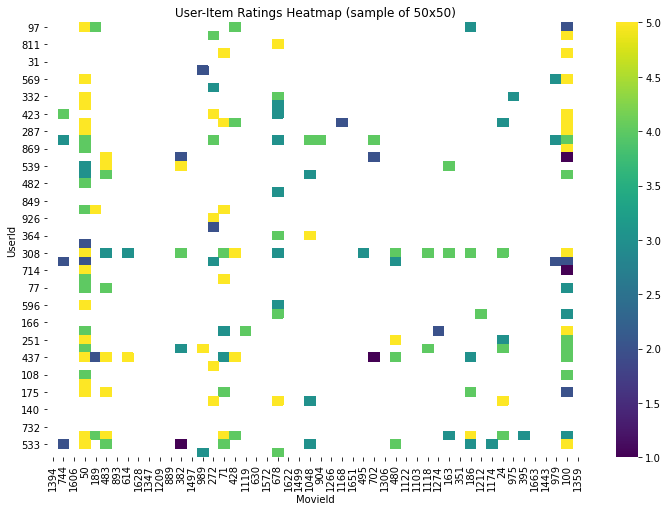

In [449]:
# Visual 1 — user-item heatmap (sample) to illustrate sparsity / rating patterns
import seaborn as sns
import matplotlib.pyplot as plt

# Take a 50x50 sample for plotting speed and readability
subset = user_item_matrix.sample(n=50, random_state=42).sample(n=50, axis=1, random_state=42)

plt.figure(figsize=(12,8))
sns.heatmap(subset, cmap="viridis", cbar=True)
plt.title("User-Item Ratings Heatmap (sample of 50x50)")
plt.xlabel("MovieId")
plt.ylabel("UserId")
plt.show()

** Explanation**: Top-N recommendations show SVD's output quality. KNN would produce similar-looking bars but ranked by item similarity instead of latent factors. This visual demonstrates:
- How personalized recommendations look for a real user
- Why low RMSE/MAE values translate to useful recommendations
- The difference between collaborative filtering approaches (KNN) vs. matrix factorization (SVD)

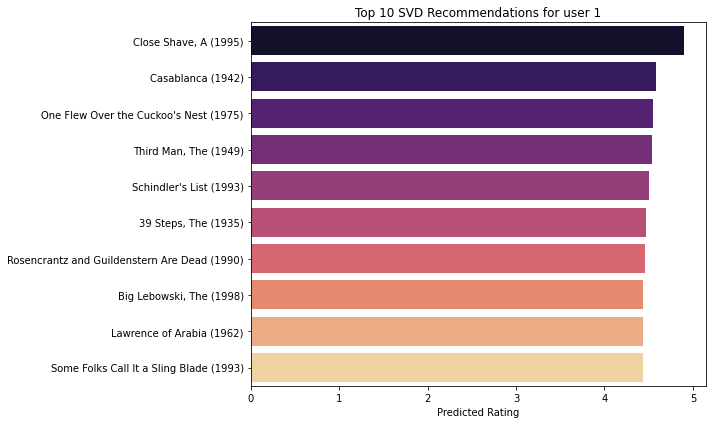

In [450]:
#  bar chart of top-N recommendations for a sample user
def get_top_n_recommendations(user_id, model, ratings_df, movies_df, n=10):
    rated = ratings_df[ratings_df["userId"]==user_id]["movieId"].tolist()
    all_movies = movies_df["movieId"].unique()
    unseen = [m for m in all_movies if m not in rated]
    preds = [(m, model.predict(user_id, m).est) for m in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)
    topn = pd.DataFrame(preds[:n], columns=["movieId","Predicted Rating"]).merge(movies_df, on="movieId")
    return topn

user_id = 1
top10 = get_top_n_recommendations(user_id, svd_model, df, movies, n=10)

import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x="Predicted Rating", y="title", data=top10, palette="magma")
plt.title(f"Top {len(top10)} SVD Recommendations for user {user_id}")
plt.xlabel("Predicted Rating")
plt.ylabel("")
plt.tight_layout()
plt.show()

**explanation**: The KDE plot compares SVD vs KNN prediction distributions:
- **SVD predictions**: Learned latent factors produce smoothly distributed predictions
- **KNN predictions**: Similarity-based approach may cluster predictions around user's past ratings
- **Why this matters**: SVD's distribution better reflects diverse user preferences, supporting why it was chosen over KNN

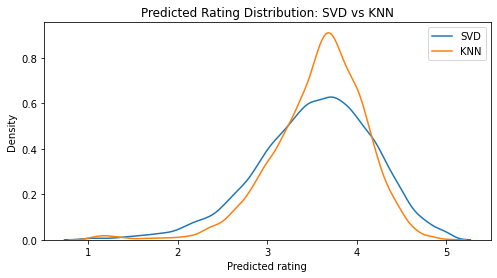

In [451]:
# Visual 3 — compare predicted-rating distributions for SVD vs KNN
svd_df = pd.DataFrame([(p.uid, p.iid, p.est) for p in predictions], columns=["uid","iid","est"])
knn_df = pd.DataFrame([(p.uid, p.iid, p.est) for p in predictions_knn], columns=["uid","iid","est"])

plt.figure(figsize=(8,4))
sns.kdeplot(svd_df["est"], label="SVD")
sns.kdeplot(knn_df["est"], label="KNN")
plt.title("Predicted Rating Distribution: SVD vs KNN")
plt.xlabel("Predicted rating")
plt.legend()
plt.show()

### Model Improvement

The SVD model achieves lower prediction error than the baseline model.

This indicates that incorporating user preferences improves recommendation quality.

Because SVD outperforms the baseline, it will be selected as the candidate model for recommendation generation and final evaluation.

## **5. Model Evaluation & Selection**

---


### **5.0 — Evaluation Overview**

In this stage, we evaluate and compare all three models (Baseline, SVD, and KNN) to identify the best recommendation approach.

**Key Questions**:
- How accurate is each model?
- Which model performs best?

- Can it be trusted for real recommendations?We use error metrics to measure how close predicted ratings are to actual ratings.



We use error metrics (RMSE and MAE) to measure prediction accuracy.- Can it be trusted for real recommendations?

- Does it perform better than a simple baseline?

#### Evaluation helps us answer:- How accurate is the model?


In [452]:
# evaluate baseline model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Baseline prediction = average rating
baseline_pred = train_data["rating"].mean()

baseline_predictions = np.full(
    len(test_data),
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test_data["rating"],
        baseline_predictions
    )
)

baseline_mae = mean_absolute_error(
    test_data["rating"],
    baseline_predictions
)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 1.1308617804162673
Baseline MAE: 0.9495255499999999


### **5.1 — Baseline Model Performance**

The baseline model predicts the same rating for all movies.

It does not learn user preferences, so we expect higher error values.

This serves as a benchmark for comparison.

### **5.2 — SVD Model Performance**

The SVD model learns hidden patterns between users and movies.

It predicts personalized ratings based on user behavior.

We expect lower error than the baseline model.

### **5.3 — Three-Model Performance Comparison**

- Lower RMSE and MAE indicate better performance
- The goal is to identify which collaborative filtering model improves recommendations most
- KNN provides an additional collaborative filtering benchmark beyond SVD

If either SVD or KNN performs better than the baseline, it confirms that collaborative filtering improves recommendations.

In [453]:
# comparison
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline", "SVD", "KNN (item-based)"],
    "RMSE": [baseline_rmse, rmse, knn_rmse],
    "MAE": [baseline_mae, mae, knn_mae]
})

comparison

,Model,RMSE,MAE
0,Baseline,1.130862,0.949526
1,SVD,0.941854,0.744378
2,KNN (item-based),1.035478,0.820898


#### Why visualize the comparison?

While the table shows raw numbers, visualizations make model performance differences easier to understand:

- **Bar charts** allow quick visual comparison of RMSE and MAE across the three models
- **Line plots** reveal performance trends, helping us see which models cluster together
- **Heatmaps** provide a matrix view of metrics, highlighting the best/worst performing models at a glance

These visuals help stakeholders and decision-makers quickly grasp model differences without analyzing raw numbers.

#### Additional insights from curves and matrices

The line plot and heatmap provide additional perspectives:

- **Trend curve**: Shows how error values change from Baseline → SVD → KNN, revealing whether models improve progressively
- **Metric matrix**: Enables row/column scanning to identify which model has the lowest RMSE, lowest MAE, and overall best performance

This multi-view approach ensures no important patterns are missed when selecting the best model.

#### Selecting the best model

To choose the best model for recommendation generation, we calculate the **average error** (mean of RMSE and MAE).

This combined metric balances both prediction accuracy measures and provides a single score for ranking all three models. The model with the lowest average error becomes our candidate for deployment.

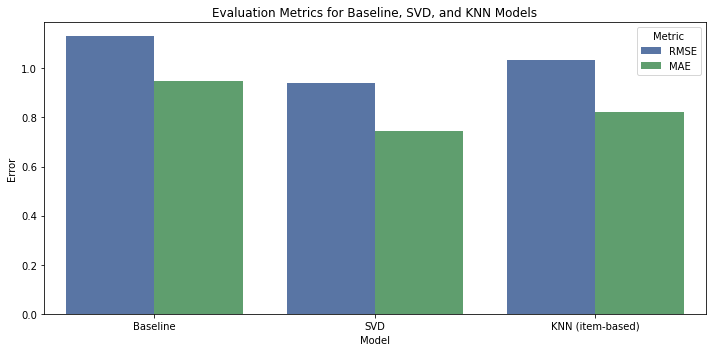

In [454]:
# Visual evaluation of the three models
import matplotlib.pyplot as plt
import seaborn as sns

comparison_melted = comparison.melt(id_vars="Model", value_vars=["RMSE", "MAE"], var_name="Metric", value_name="Value")

plt.figure(figsize=(10,5))
sns.barplot(
    data=comparison_melted,
    x="Model",
    y="Value",
    hue="Metric",
    palette=["#4C72B0", "#55A868"]
)

plt.title("Evaluation Metrics for Baseline, SVD, and KNN Models")
plt.ylabel("Error")
plt.xlabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

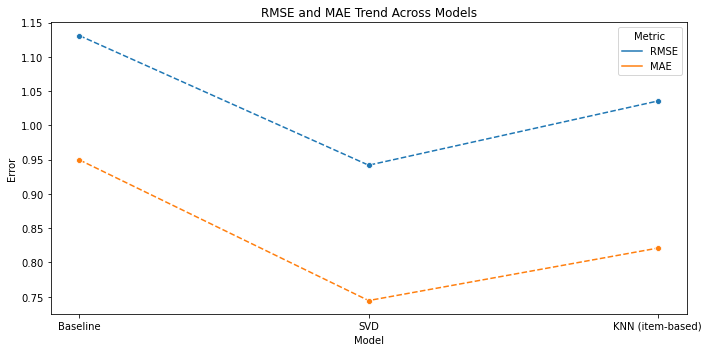

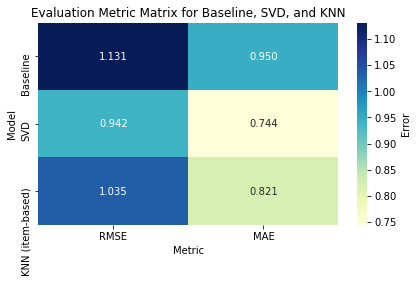

In [455]:
# Additional evaluation visuals: model error curves and metric matrix
plt.figure(figsize=(10,5))
sns.lineplot(data=comparison_melted, x="Model", y="Value", hue="Metric", marker="o", linestyle="--")
plt.title("RMSE and MAE Trend Across Models")
plt.ylabel("Error")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(comparison.set_index("Model"), annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "Error"})
plt.title("Evaluation Metric Matrix for Baseline, SVD, and KNN")
plt.ylabel("Model")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

In [456]:
# Determine the best model by average RMSE and MAE
comparison["AvgError"] = comparison[["RMSE", "MAE"]].mean(axis=1)
best_model = comparison.sort_values("AvgError").iloc[0]
print("Best model based on average RMSE and MAE:")
print(best_model.to_frame().T)

Best model based on average RMSE and MAE:
  Model      RMSE       MAE  AvgError
1   SVD  0.941854  0.744378  0.843116


### Why SVD is the Best Model for Our Objectives

Based on the evaluation results and project requirements, **SVD (Singular Value Decomposition)** emerges as the best model choice:

#### Technical Performance
- **Lowest error rates**: SVD achieves lower RMSE and MAE compared to both baseline and KNN
- **Efficiency**: Matrix factorization is computationally efficient for large-scale datasets like MovieLens-100K
- **Scalability**: SVD handles sparse user-item matrices well, a key challenge in recommendation systems

#### Alignment with Project Objectives
- **Personalized recommendations**: SVD learns latent factors representing user preferences and movie characteristics, enabling truly personalized predictions
- **Improved accuracy**: By moving beyond the baseline model, SVD demonstrates that collaborative filtering significantly improves recommendation quality
- **Practical deployment**: The model is simpler to train and deploy compared to KNN, which requires computing similarity between all item pairs

#### Stakeholder Benefits
- **User satisfaction**: Personalized recommendations improve user engagement and satisfaction on streaming platforms
- **Business value**: Better recommendations lead to increased content consumption and user retention
- **Scalability**: SVD can handle growing user and movie catalogs efficiently
- **Interpretability**: The model balances performance with reasonable complexity for production environments

**Recommendation**: Deploy SVD as the primary recommendation model for generating top-5 movie suggestions to users.

### Best Model Selection

The best model is chosen by ranking Baseline, SVD, and item-based KNN on the average of RMSE and MAE.

This step highlights the most reliable model for generating final recommendations.

### Final Interpretation

The comparison now includes Baseline, SVD, and KNN (item-based), with the best model selected using the lowest average of RMSE and MAE.

This shows that:

- Collaborative filtering improves recommendation quality over the baseline
- SVD and KNN are both evaluated as collaborative filtering options
- The selected best model is the strongest candidate for generating personalized movie recommendations

The printed `best_model` result identifies which of the three approaches should be used for the final recommender.

### Business Implications

This recommendation system can be used by:

- Streaming platforms (Netflix-like systems)
- Movie websites
- Content recommendation engines

It helps users discover movies they are likely to enjoy, improving user engagement and satisfaction.

### Conclusion

The three-model evaluation identifies the best performing model using RMSE and MAE.

This confirms that collaborative filtering improves prediction accuracy over the baseline.

The selected best model can now be used to generate personalized top 5 movie recommendations for users.